# 07. Сопоставление кластеров во времени

Номера Louvain-кластеров не сохраняют смысл между месяцами: кластер `0` в январе не обязан быть тем же кластером `0` в феврале. Здесь мы сопоставляем месячные кластеры по экономическим профилям, а затем отдельно отслеживаем переходы муниципалитетов.

In [1]:
import pandas as pd
import numpy as np

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import pairwise_distances

## 1. Загрузка динамической панели

Подгружаем экономические признаки и месячные cluster labels.

In [2]:
features = pd.read_parquet(
    "../data/processed/features_basic.parquet"
)

clusters = pd.read_parquet(
    "../data/processed/clusters_all_months.parquet"
)

features["date"] = pd.to_datetime(features["date"])
clusters["date"] = pd.to_datetime(clusters["date"])

print("features:", features.shape)
print("clusters:", clusters.shape)

features: (50521, 14)
clusters: (50521, 3)


In [3]:
model_features = [
    "food_share",
    "health_share",
    "marketplaces_share",
    "catering_share",
    "transport_share"
]

## 2. Формирование таблицы cluster × municipality

Объединяем назначения кластеров с исходными экономическими признаками.

In [4]:
cluster_data = clusters.merge(
    features[
        ["territory_id", "date"] + model_features
    ],
    on=["territory_id", "date"],
    how="left"
)

print(cluster_data.shape)
cluster_data.head()

(50521, 8)


,territory_id,date,cluster,food_share,health_share,marketplaces_share,catering_share,transport_share
0,1,2023-01-01,18,0.536851,0.088707,0.174832,0.079704,0.119905
1,2,2023-01-01,18,0.507017,0.099659,0.173789,0.092524,0.127012
2,3,2023-01-01,9,0.616495,0.078085,0.186730,0.032923,0.085767
3,4,2023-01-01,9,0.584708,0.095122,0.171672,0.034803,0.113696
4,5,2023-01-01,9,0.607010,0.084942,0.173373,0.027259,0.107415


## 3. Профили и размеры кластеров

Для каждого месячного кластера вычисляем средние экономические доли и число муниципалитетов.

In [5]:
cluster_profiles = (
    cluster_data
    .groupby(
        ["date", "cluster"]
    )[model_features]
    .mean()
    .reset_index()
)

cluster_profiles.head()

,date,cluster,food_share,health_share,marketplaces_share,catering_share,transport_share
0,2023-01-01,0,0.714487,0.072052,0.109116,0.030464,0.073881
1,2023-01-01,1,0.658027,0.091985,0.087570,0.048268,0.114150
2,2023-01-01,2,0.642972,0.083364,0.104826,0.069114,0.099725
3,2023-01-01,3,0.679651,0.081093,0.132084,0.024224,0.082948
4,2023-01-01,4,0.739960,0.071853,0.065875,0.029745,0.092568


In [6]:
cluster_sizes = (
    cluster_data
    .groupby(
        ["date", "cluster"]
    )
    .size()
    .reset_index(
        name="n_municipalities"
    )
)

cluster_profiles = cluster_profiles.merge(
    cluster_sizes,
    on=["date", "cluster"],
    how="left"
)

cluster_profiles.head()

,date,cluster,food_share,health_share,marketplaces_share,catering_share,transport_share,n_municipalities
0,2023-01-01,0,0.714487,0.072052,0.109116,0.030464,0.073881,160
1,2023-01-01,1,0.658027,0.091985,0.087570,0.048268,0.114150,81
2,2023-01-01,2,0.642972,0.083364,0.104826,0.069114,0.099725,92
3,2023-01-01,3,0.679651,0.081093,0.132084,0.024224,0.082948,97
4,2023-01-01,4,0.739960,0.071853,0.065875,0.029745,0.092568,165


## 4. Функция выравнивания соседних месяцев

Сопоставляем кластеры двух соседних месяцев по расстоянию между их экономическими профилями с помощью оптимального соответствия.

In [7]:
def align_two_months(
    profiles_prev,
    profiles_next,
    feature_columns
):
    
    prev_clusters = profiles_prev["cluster"].to_numpy()
    next_clusters = profiles_next["cluster"].to_numpy()

    X_prev = profiles_prev[
        feature_columns
    ].to_numpy()

    X_next = profiles_next[
        feature_columns
    ].to_numpy()

    cost_matrix = pairwise_distances(
        X_prev,
        X_next,
        metric="euclidean"
    )

    row_ind, col_ind = linear_sum_assignment(
        cost_matrix
    )

    matches = []

    for i, j in zip(row_ind, col_ind):
        matches.append({
            "cluster_prev": int(prev_clusters[i]),
            "cluster_next": int(next_clusters[j]),
            "distance": float(cost_matrix[i, j])
        })

    return pd.DataFrame(matches)

## 5. Тест на одной паре месяцев

Сначала проверяем процедуру на январе и феврале 2023 года.

In [8]:
date_prev = pd.Timestamp("2023-01-01")
date_next = pd.Timestamp("2023-02-01")

profiles_prev = cluster_profiles[
    cluster_profiles["date"] == date_prev
].copy()

profiles_next = cluster_profiles[
    cluster_profiles["date"] == date_next
].copy()

matches_test = align_two_months(
    profiles_prev,
    profiles_next,
    model_features
)

matches_test

,cluster_prev,cluster_next,distance
0,0,0,0.015420
1,1,1,0.024067
2,2,15,0.016716
3,3,8,0.013025
4,4,6,0.046573
5,5,10,0.013866
6,6,3,0.014274
7,7,16,0.011016
8,8,18,0.054419
9,9,12,0.023012


In [9]:
matches_test["distance"].describe()

count    22.000000
mean      0.024717
std       0.012844
min       0.011016
25%       0.016501
50%       0.022352
75%       0.027408
max       0.056258
Name: distance, dtype: float64

In [10]:
matches_test.sort_values(
    "distance"
).head(10)

,cluster_prev,cluster_next,distance
7,7,16,0.011016
3,3,8,0.013025
5,5,10,0.013866
6,6,3,0.014274
0,0,0,0.015420
15,15,2,0.016429
2,2,15,0.016716
20,21,21,0.016802
21,22,20,0.016882
19,19,14,0.017013


## 6. Изменение числа кластеров во времени

Смотрим, как меняется количество месячных сообществ.

In [11]:
cluster_counts = (
    cluster_profiles
    .groupby("date")["cluster"]
    .nunique()
    .reset_index(name="n_clusters")
)

cluster_counts

,date,n_clusters
0,2023-01-01,23
1,2023-02-01,22
2,2023-03-01,20
3,2023-04-01,22
4,2023-05-01,25
5,2023-06-01,23
6,2023-07-01,21
7,2023-08-01,22
8,2023-09-01,23
9,2023-10-01,21


## 7. Выравнивание всех 24 месяцев

Теперь применяем ту же процедуру последовательно ко всем соседним месяцам.

In [12]:
all_matches = []

dates = sorted(
    cluster_profiles["date"].unique()
)

for i in range(len(dates) - 1):

    date_prev = dates[i]
    date_next = dates[i + 1]

    profiles_prev = cluster_profiles[
        cluster_profiles["date"] == date_prev
    ].copy()

    profiles_next = cluster_profiles[
        cluster_profiles["date"] == date_next
    ].copy()

    matches = align_two_months(
        profiles_prev,
        profiles_next,
        model_features
    )

    matches["date_prev"] = date_prev
    matches["date_next"] = date_next

    all_matches.append(matches)

matches_all = pd.concat(
    all_matches,
    ignore_index=True
)

print("Количество сопоставлений:", len(matches_all))
matches_all.head(20)

Количество сопоставлений: 473


,cluster_prev,cluster_next,distance,date_prev,date_next
0,0,0,0.015420,2023-01-01,2023-02-01
1,1,1,0.024067,2023-01-01,2023-02-01
2,2,15,0.016716,2023-01-01,2023-02-01
3,3,8,0.013025,2023-01-01,2023-02-01
4,4,6,0.046573,2023-01-01,2023-02-01
5,5,10,0.013866,2023-01-01,2023-02-01
6,6,3,0.014274,2023-01-01,2023-02-01
7,7,16,0.011016,2023-01-01,2023-02-01
8,8,18,0.054419,2023-01-01,2023-02-01
9,9,12,0.023012,2023-01-01,2023-02-01


## 8. Качество сопоставления

Анализируем распределение расстояний между сопоставленными профилями.

In [13]:
matches_all["distance"].describe()

count    473.000000
mean       0.025493
std        0.019528
min        0.002078
25%        0.015066
50%        0.020465
75%        0.029820
max        0.170087
Name: distance, dtype: float64

In [14]:
matches_all.sort_values(
    "distance",
    ascending=False
).head(20)

,cluster_prev,cluster_next,distance,date_prev,date_next
210,19,2,0.170087,2023-10-01,2023-11-01
191,22,19,0.141086,2023-09-01,2023-10-01
454,0,3,0.134548,2024-11-01,2024-12-01
345,12,23,0.121450,2024-05-01,2024-06-01
214,2,19,0.114025,2023-11-01,2023-12-01
231,19,15,0.113177,2023-11-01,2023-12-01
253,0,0,0.107401,2024-01-01,2024-02-01
273,0,11,0.103697,2024-02-01,2024-03-01
249,20,18,0.102934,2023-12-01,2024-01-01
176,7,15,0.097675,2023-09-01,2023-10-01


## 9. Сводная оценка alignment

Получаем агрегированную характеристику качества межвременного сопоставления.

In [15]:
alignment_quality = (
    matches_all
    .groupby(
        ["date_prev", "date_next"]
    )["distance"]
    .agg(
        mean_distance="mean",
        median_distance="median",
        max_distance="max"
    )
    .reset_index()
)

alignment_quality

,date_prev,date_next,mean_distance,median_distance,max_distance
0,2023-01-01,2023-02-01,0.024717,0.022352,0.056258
1,2023-02-01,2023-03-01,0.018244,0.016933,0.042844
2,2023-03-01,2023-04-01,0.023828,0.022521,0.047791
3,2023-04-01,2023-05-01,0.016747,0.015918,0.030070
4,2023-05-01,2023-06-01,0.017065,0.016907,0.042274
5,2023-06-01,2023-07-01,0.022134,0.020484,0.054690
6,2023-07-01,2023-08-01,0.025007,0.021023,0.047363
7,2023-08-01,2023-09-01,0.020552,0.016595,0.043137
8,2023-09-01,2023-10-01,0.035016,0.023597,0.141086
9,2023-10-01,2023-11-01,0.044798,0.034467,0.170087


## 10. Переходы на уровне кластеров

Дополнительно учитываем состав муниципалитетов в кластерах.

In [16]:
cluster_members = (
    cluster_data
    .groupby(["date", "cluster"])["territory_id"]
    .apply(set)
    .reset_index(name="members")
)

cluster_members.head()

,date,cluster,members
0,2023-01-01,0,"{2054, 2057, 531, 533, 1047, 536, 1049, 538, 1..."
1,2023-01-01,1,"{30, 31, 32, 33, 34, 35, 545, 37, 40, 41, 43, ..."
2,2023-01-01,2,"{23, 38, 42, 44, 49, 55, 57, 2620, 2621, 66, 5..."
3,2023-01-01,3,"{512, 1537, 2050, 518, 1543, 1544, 521, 1546, ..."
4,2023-01-01,4,"{517, 519, 523, 525, 528, 532, 541, 542, 550, ..."


## 11. Jaccard similarity

Jaccard сравнивает множества муниципалитетов двух кластеров и позволяет дополнить сравнение только по экономическому профилю.

In [17]:
def jaccard_similarity(set_a, set_b):
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)

    if union == 0:
        return 0.0

    return intersection / union

## 12. Матрица переходов между кластерами

Строим переходы от кластеров одного месяца к кластерам следующего месяца.

In [18]:
def build_transition_matrix(
    date_prev,
    date_next,
    cluster_profiles,
    cluster_members,
    feature_columns
):
    prev_profiles = cluster_profiles[
        cluster_profiles["date"] == date_prev
    ].copy()

    next_profiles = cluster_profiles[
        cluster_profiles["date"] == date_next
    ].copy()

    prev_members = cluster_members[
        cluster_members["date"] == date_prev
    ].copy()

    next_members = cluster_members[
        cluster_members["date"] == date_next
    ].copy()

    rows = []

    for _, prev_row in prev_profiles.iterrows():

        prev_cluster = prev_row["cluster"]
        prev_set = prev_members.loc[
            prev_members["cluster"] == prev_cluster,
            "members"
        ].iloc[0]

        for _, next_row in next_profiles.iterrows():

            next_cluster = next_row["cluster"]
            next_set = next_members.loc[
                next_members["cluster"] == next_cluster,
                "members"
            ].iloc[0]

            profile_distance = np.linalg.norm(
                prev_row[feature_columns].to_numpy(dtype=float)
                - next_row[feature_columns].to_numpy(dtype=float)
            )

            jaccard = jaccard_similarity(
                prev_set,
                next_set
            )

            rows.append({
                "date_prev": date_prev,
                "date_next": date_next,
                "cluster_prev": int(prev_cluster),
                "cluster_next": int(next_cluster),
                "profile_distance": profile_distance,
                "jaccard": jaccard
            })

    return pd.DataFrame(rows)

In [19]:
transition_jan_feb = build_transition_matrix(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-02-01"),
    cluster_profiles,
    cluster_members,
    model_features
)

transition_jan_feb.head()

,date_prev,date_next,cluster_prev,cluster_next,profile_distance,jaccard
0,2023-01-01,2023-02-01,0,0,0.015420,0.246032
1,2023-01-01,2023-02-01,0,1,0.085553,0.000000
2,2023-01-01,2023-02-01,0,2,0.057722,0.004115
3,2023-01-01,2023-02-01,0,3,0.044269,0.016807
4,2023-01-01,2023-02-01,0,4,0.103782,0.000000


In [20]:
transition_jan_feb.sort_values(
    "jaccard",
    ascending=False
).head(20)

,date_prev,date_next,cluster_prev,cluster_next,profile_distance,jaccard
432,2023-01-01,2023-02-01,19,14,0.017013,0.673611
483,2023-01-01,2023-02-01,21,21,0.016802,0.645455
504,2023-01-01,2023-02-01,22,20,0.016882,0.616071
59,2023-01-01,2023-02-01,2,15,0.016716,0.525641
120,2023-01-01,2023-02-01,5,10,0.013866,0.488636
403,2023-01-01,2023-02-01,18,7,0.021691,0.455497
268,2023-01-01,2023-02-01,12,4,0.024147,0.437500
94,2023-01-01,2023-02-01,4,6,0.046573,0.384181
210,2023-01-01,2023-02-01,9,12,0.023012,0.383838
240,2023-01-01,2023-02-01,10,20,0.023360,0.347458


## 13. Сходство экономических профилей

Добавляем атрибутивную компоненту к оценке переходов.

In [21]:
transition_jan_feb["profile_similarity"] = (
    1
    - transition_jan_feb["profile_distance"]
    / transition_jan_feb["profile_distance"].max()
)

## 14. Итоговый transition score

Комбинируем сходство профилей и совпадение состава муниципалитетов.

In [22]:
transition_jan_feb["transition_score"] = (
    0.5 * transition_jan_feb["profile_similarity"]
    + 0.5 * transition_jan_feb["jaccard"]
)

In [23]:
transition_jan_feb.sort_values(
    "transition_score",
    ascending=False
).head(20)

,date_prev,date_next,cluster_prev,cluster_next,profile_distance,jaccard,profile_similarity,transition_score
432,2023-01-01,2023-02-01,19,14,0.017013,0.673611,0.945652,0.809631
483,2023-01-01,2023-02-01,21,21,0.016802,0.645455,0.946326,0.795890
504,2023-01-01,2023-02-01,22,20,0.016882,0.616071,0.946071,0.781071
59,2023-01-01,2023-02-01,2,15,0.016716,0.525641,0.946600,0.736120
120,2023-01-01,2023-02-01,5,10,0.013866,0.488636,0.955703,0.722170
403,2023-01-01,2023-02-01,18,7,0.021691,0.455497,0.930706,0.693102
268,2023-01-01,2023-02-01,12,4,0.024147,0.437500,0.922863,0.680181
210,2023-01-01,2023-02-01,9,12,0.023012,0.383838,0.926487,0.655163
240,2023-01-01,2023-02-01,10,20,0.023360,0.347458,0.925375,0.636416
94,2023-01-01,2023-02-01,4,6,0.046573,0.384181,0.851221,0.617701


## 15. Переходы на уровне муниципалитетов

Теперь отслеживаем уже конкретные municipality-month переходы между кластерами.

In [24]:
def build_municipality_transitions(
    date_prev,
    date_next,
    cluster_data
):
    prev = cluster_data[
        cluster_data["date"] == date_prev
    ][["territory_id", "cluster"]].rename(
        columns={"cluster": "cluster_prev"}
    )

    next_ = cluster_data[
        cluster_data["date"] == date_next
    ][["territory_id", "cluster"]].rename(
        columns={"cluster": "cluster_next"}
    )

    common = prev.merge(
        next_,
        on="territory_id",
        how="inner"
    )

    transitions = (
        common
        .groupby(
            ["cluster_prev", "cluster_next"]
        )
        .agg(
            n_municipalities=("territory_id", "count")
        )
        .reset_index()
    )

    transitions["date_prev"] = date_prev
    transitions["date_next"] = date_next

    return transitions

In [25]:
municipality_transitions_jan_feb = build_municipality_transitions(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-02-01"),
    cluster_data
)

municipality_transitions_jan_feb.sort_values(
    "n_municipalities",
    ascending=False
).head(20)

,cluster_prev,cluster_next,n_municipalities,date_prev,date_next
137,19,14,97,2023-01-01,2023-02-01
126,18,7,87,2023-01-01,2023-02-01
18,2,15,82,2023-01-01,2023-02-01
65,9,12,76,2023-01-01,2023-02-01
147,21,21,71,2023-01-01,2023-02-01
27,4,0,70,2023-01-01,2023-02-01
148,22,20,69,2023-01-01,2023-02-01
31,4,6,68,2023-01-01,2023-02-01
0,0,0,62,2023-01-01,2023-02-01
76,12,4,56,2023-01-01,2023-02-01


In [26]:
prev_sizes = (
    cluster_data[
        cluster_data["date"] == pd.Timestamp("2023-01-01")
    ]
    .groupby("cluster")["territory_id"]
    .nunique()
    .rename("prev_cluster_size")
)

municipality_transitions_jan_feb = (
    municipality_transitions_jan_feb
    .merge(
        prev_sizes,
        left_on="cluster_prev",
        right_index=True,
        how="left"
    )
)

municipality_transitions_jan_feb["share_from_prev"] = (
    municipality_transitions_jan_feb["n_municipalities"]
    / municipality_transitions_jan_feb["prev_cluster_size"]
)

In [27]:
municipality_transitions_jan_feb.sort_values(
    "share_from_prev",
    ascending=False
).head(20)

,cluster_prev,cluster_next,n_municipalities,date_prev,date_next,prev_cluster_size,share_from_prev
148,22,20,69,2023-01-01,2023-02-01,69,1.000000
140,20,14,21,2023-01-01,2023-02-01,23,0.913043
18,2,15,82,2023-01-01,2023-02-01,92,0.891304
147,21,21,71,2023-01-01,2023-02-01,80,0.887500
137,19,14,97,2023-01-01,2023-02-01,110,0.881818
69,10,20,41,2023-01-01,2023-02-01,47,0.872340
36,5,10,43,2023-01-01,2023-02-01,59,0.728814
76,12,4,56,2023-01-01,2023-02-01,79,0.708861
122,17,11,20,2023-01-01,2023-02-01,30,0.666667
72,11,5,53,2023-01-01,2023-02-01,87,0.609195


## 16. Переходы за весь период

Объединяем переходы всех 23 пар соседних месяцев.

In [28]:
all_municipality_transitions = []

dates = sorted(
    cluster_data["date"].unique()
)

for i in range(len(dates) - 1):

    date_prev = dates[i]
    date_next = dates[i + 1]

    transitions = build_municipality_transitions(
        date_prev,
        date_next,
        cluster_data
    )

    prev_sizes = (
        cluster_data[
            cluster_data["date"] == date_prev
        ]
        .groupby("cluster")["territory_id"]
        .nunique()
        .rename("prev_cluster_size")
    )

    transitions = transitions.merge(
        prev_sizes,
        left_on="cluster_prev",
        right_index=True,
        how="left"
    )

    transitions["share_from_prev"] = (
        transitions["n_municipalities"]
        / transitions["prev_cluster_size"]
    )

    all_municipality_transitions.append(
        transitions
    )

municipality_transitions_all = pd.concat(
    all_municipality_transitions,
    ignore_index=True
)

print(
    "Всего переходов кластер → кластер:",
    len(municipality_transitions_all)
)

Всего переходов кластер → кластер: 3210


In [29]:
municipality_transitions_all.sort_values(
    "n_municipalities",
    ascending=False
).head(30)

,cluster_prev,cluster_next,n_municipalities,date_prev,date_next,prev_cluster_size,share_from_prev
2849,7,3,136,2024-09-01,2024-10-01,186,0.731183
2652,1,7,132,2024-08-01,2024-09-01,165,0.800000
488,5,5,125,2023-04-01,2023-05-01,178,0.702247
1437,5,3,119,2023-11-01,2023-12-01,153,0.777778
2958,3,6,113,2024-10-01,2024-11-01,194,0.582474
3022,11,15,111,2024-10-01,2024-11-01,187,0.593583
2519,2,1,109,2024-07-01,2024-08-01,214,0.509346
1746,9,13,107,2024-01-01,2024-02-01,151,0.708609
290,20,16,107,2023-02-01,2023-03-01,112,0.955357
937,10,14,106,2023-07-01,2023-08-01,143,0.741259


## 17. Правило доминирующего перехода

Проверяем, в какой доле случаев муниципалитет сохраняет один доминирующий кластер следующего месяца.

In [30]:
municipality_transitions_all[
    municipality_transitions_all["share_from_prev"] >= 0.7
].sort_values(
    "share_from_prev",
    ascending=False
).head(30)

,cluster_prev,cluster_next,n_municipalities,date_prev,date_next,prev_cluster_size,share_from_prev
3207,21,17,63,2024-11-01,2024-12-01,63,1.000000
585,21,22,65,2023-04-01,2023-05-01,65,1.000000
729,22,21,66,2023-05-01,2023-06-01,66,1.000000
1950,2,9,5,2024-03-01,2024-04-01,5,1.000000
2804,22,21,74,2024-08-01,2024-09-01,74,1.000000
1949,1,9,24,2024-03-01,2024-04-01,24,1.000000
1801,17,19,72,2024-01-01,2024-02-01,72,1.000000
1529,18,22,70,2023-11-01,2023-12-01,70,1.000000
728,21,22,26,2023-05-01,2023-06-01,26,1.000000
148,22,20,69,2023-01-01,2023-02-01,69,1.000000


In [31]:
municipality_transitions_all.to_parquet(
    "../data/processed/municipality_cluster_transitions.parquet",
    index=False
)

print("Переходы сохранены.")

Переходы сохранены.


## 18. Агрегирование переходов

Формируем компактную таблицу для анализа устойчивости кластеров.

In [32]:
transition_summary = (
    municipality_transitions_all
    .groupby(["date_prev", "date_next", "cluster_prev"])
    .agg(
        prev_cluster_size=("prev_cluster_size", "first"),
        best_next_size=("n_municipalities", "max"),
        n_possible_transitions=("cluster_next", "nunique")
    )
    .reset_index()
)

transition_summary["best_share"] = (
    transition_summary["best_next_size"]
    / transition_summary["prev_cluster_size"]
)

transition_summary.head()

,date_prev,date_next,cluster_prev,prev_cluster_size,best_next_size,n_possible_transitions,best_share
0,2023-01-01,2023-02-01,0,160,62,9,0.387500
1,2023-01-01,2023-02-01,1,81,45,5,0.555556
2,2023-01-01,2023-02-01,2,92,82,5,0.891304
3,2023-01-01,2023-02-01,3,97,34,8,0.350515
4,2023-01-01,2023-02-01,4,165,70,6,0.424242


## 19. Месячная преемственность

Получаем динамический показатель continuity, который показывает, насколько стабильно сохраняется кластерная структура.

In [33]:
monthly_continuity = (
    transition_summary
    .groupby(["date_prev", "date_next"])
    .apply(
        lambda g: np.average(
            g["best_share"],
            weights=g["prev_cluster_size"]
        )
    )
    .reset_index(name="weighted_continuity")
)

monthly_continuity

,date_prev,date_next,weighted_continuity
0,2023-01-01,2023-02-01,0.543164
1,2023-02-01,2023-03-01,0.551611
2,2023-03-01,2023-04-01,0.477431
3,2023-04-01,2023-05-01,0.512447
4,2023-05-01,2023-06-01,0.578029
5,2023-06-01,2023-07-01,0.613497
6,2023-07-01,2023-08-01,0.571025
7,2023-08-01,2023-09-01,0.542021
8,2023-09-01,2023-10-01,0.552869
9,2023-10-01,2023-11-01,0.543985


In [34]:
monthly_continuity.sort_values(
    "weighted_continuity"
).head(10)

,date_prev,date_next,weighted_continuity
2,2023-03-01,2023-04-01,0.477431
16,2024-05-01,2024-06-01,0.501679
11,2023-12-01,2024-01-01,0.503566
13,2024-02-01,2024-03-01,0.508662
10,2023-11-01,2023-12-01,0.510750
3,2023-04-01,2023-05-01,0.512447
22,2024-11-01,2024-12-01,0.517619
18,2024-07-01,2024-08-01,0.519387
21,2024-10-01,2024-11-01,0.521989
14,2024-03-01,2024-04-01,0.535766


In [35]:
monthly_continuity.sort_values(
    "weighted_continuity",
    ascending=False
).head(10)

,date_prev,date_next,weighted_continuity
5,2023-06-01,2023-07-01,0.613497
12,2024-01-01,2024-02-01,0.587355
4,2023-05-01,2023-06-01,0.578029
6,2023-07-01,2023-08-01,0.571025
17,2024-06-01,2024-07-01,0.560940
20,2024-09-01,2024-10-01,0.554762
8,2023-09-01,2023-10-01,0.552869
1,2023-02-01,2023-03-01,0.551611
19,2024-08-01,2024-09-01,0.547755
9,2023-10-01,2023-11-01,0.543985


## 20. Визуальная проверка

Строим графики для интерпретации динамики переходов.

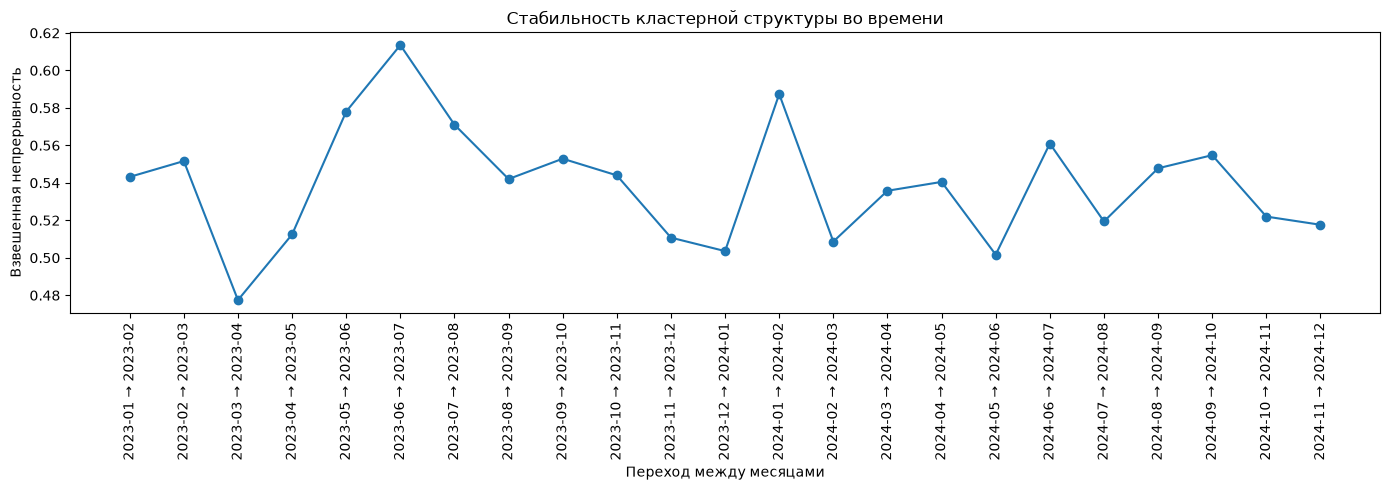

In [36]:
import matplotlib.pyplot as plt

plot_data = monthly_continuity.copy()

plot_data["period"] = (
    plot_data["date_prev"].dt.strftime("%Y-%m")
    + " → "
    + plot_data["date_next"].dt.strftime("%Y-%m")
)

plt.figure(figsize=(14, 5))

plt.plot(
    plot_data["period"],
    plot_data["weighted_continuity"],
    marker="o"
)

plt.ylabel("Взвешенная непрерывность")
plt.xlabel("Переход между месяцами")
plt.title("Стабильность кластерной структуры во времени")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 21. Дополнительная проверка крупных кластеров

Отдельно смотрим на кластеры с достаточным размером, чтобы не делать выводы по очень маленьким группам.

In [37]:
large_cluster_summary = transition_summary[
    transition_summary["prev_cluster_size"] >= 20
].copy()

large_monthly_continuity = (
    large_cluster_summary
    .groupby(["date_prev", "date_next"])
    .apply(
        lambda g: np.average(
            g["best_share"],
            weights=g["prev_cluster_size"]
        )
    )
    .reset_index(name="weighted_continuity")
)

large_monthly_continuity

,date_prev,date_next,weighted_continuity
0,2023-01-01,2023-02-01,0.543164
1,2023-02-01,2023-03-01,0.551611
2,2023-03-01,2023-04-01,0.477431
3,2023-04-01,2023-05-01,0.512447
4,2023-05-01,2023-06-01,0.578029
5,2023-06-01,2023-07-01,0.613497
6,2023-07-01,2023-08-01,0.571025
7,2023-08-01,2023-09-01,0.542021
8,2023-09-01,2023-10-01,0.552869
9,2023-10-01,2023-11-01,0.542762
